# Run Any Kind of Logistic Regression (Binomial, Multinomial, etc.)

### Authors: Calvin Howard.

#### Last updated: March 16, 2024

Use this to run/test a statistical model on a spreadsheet.

Notes:
- To best use this notebook, you should be familar with GLM design and Contrast Matrix design. See this webpage to get started:
[FSL's GLM page](https://fsl.fmrib.ox.ac.uk/fsl/fslwiki/GLM)

# 00 - Import CSV with All Data
**The CSV is expected to be in this format**
- ID and absolute paths to niftis are critical
```
+-----+----------------------------+--------------+--------------+--------------+
| ID  | Nifti_File_Path            | Covariate_1  | Covariate_2  | Covariate_3  |
+-----+----------------------------+--------------+--------------+--------------+
| 1   | /path/to/file1.nii.gz      | 0.5          | 1.2          | 3.4          |
| 2   | /path/to/file2.nii.gz      | 0.7          | 1.4          | 3.1          |
| 3   | /path/to/file3.nii.gz      | 0.6          | 1.5          | 3.5          |
| 4   | /path/to/file4.nii.gz      | 0.9          | 1.1          | 3.2          |
| ... | ...                        | ...          | ...          | ...          |
+-----+----------------------------+--------------+--------------+--------------+
```

Prep Output Directory

In [55]:
# Specify where you want to save your results to
out_dir = '/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/atrophy_seeds_2023/Figures/supplement_validation_diagnostic/csf'

Import Data

In [56]:
# Specify the path to your CSV file containing NIFTI paths
input_csv_path = '/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_Atrophy/metadata/cleaned_information/discovery.csv'
sheet = None

In [57]:
from calvin_utils.permutation_analysis_utils.statsmodels_palm import CalvinStatsmodelsPalm
# Instantiate the PalmPrepararation class
cal_palm = CalvinStatsmodelsPalm(input_csv_path=input_csv_path, output_dir=out_dir, sheet=sheet)
# Call the process_nifti_paths method
data_df = cal_palm.read_and_display_data()
data_df

,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,GM_Subcortex,...,CTh_Occipital,CTh_Frontal,CTh_Parietal,CTh_Temporal,CTh_Subcortex,Q4,TOTAL11,TOTALMOD,DX_BASELINE,DX_M12
0,002_S_0295,-26319.381520,373.297842,-746.688684,-24081.964640,-32607.592110,-18245.868460,-32777.023890,-23248.955500,1038.504856,...,-105.389274,120.695319,53.378091,-22.450096,0,1.0,3.00,4.00,Normal,Normal
1,002_S_0413,-13670.888710,5009.504947,-449.838607,-8185.340726,-13903.977170,-6191.852471,-13476.493390,-4562.384254,6161.244622,...,-143.744122,203.108923,61.058778,78.520462,0,1.0,3.33,4.33,Normal,Normal
2,002_S_0954,-27912.718120,267.960111,-26.245064,-14384.382220,1174.325661,-13108.994170,-11969.395470,24935.280210,-9318.628653,...,-174.288965,31.148917,-278.336762,-143.373844,0,9.0,10.67,21.67,MCI,Alzheimer
3,002_S_4270,-9935.777020,7367.389634,98.187832,-8652.081921,3367.575080,-6328.324270,-3847.122951,2285.939202,12356.434000,...,-11.128905,-53.855001,-110.316638,1.770256,0,2.0,5.00,7.00,NaN,NaN
4,003_S_1057,-3441.984646,8102.022733,-157.009052,-11631.937370,-11106.858210,-14756.563150,-14732.642180,2344.896594,34023.478140,...,-154.821848,274.997385,-146.948766,35.910303,0,8.0,11.33,20.33,MCI,MCI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,057_S_1373,-45863.712820,-18424.377380,-4071.419956,-33255.478800,-44549.401870,-33451.642240,-64501.871590,4310.131198,24644.932300,...,-270.153015,-981.542856,-1000.624078,-921.559711,0,10.0,36.00,50.00,Alzheimer,Alzheimer
196,070_S_4692,-33496.157720,-11584.240630,-2425.821265,-38719.035680,-69322.966190,-46751.080130,-64821.186130,-22768.891620,7895.301840,...,50.862945,-14.785310,-10.781394,-178.887746,0,8.0,18.00,28.00,NaN,NaN
197,073_S_0565,-30453.159660,-46589.059190,-3821.029220,-18475.202970,-33873.945240,-33623.937740,-43214.788920,-4771.857012,-68379.286760,...,-173.586634,-468.159693,-382.729251,-384.619813,0,10.0,26.67,40.67,Alzheimer,Alzheimer
198,114_S_0228,-26706.829570,-18673.421780,-3494.089241,-23203.940710,-34536.844220,-20813.726580,-56633.528990,9781.066973,-3902.907459,...,-213.208901,-666.828584,-519.796650,-575.825015,0,7.0,28.00,36.00,Alzheimer,NaN


In [59]:
data_df['DX_BASELINE'].value_counts()

DX_BASELINE
Normal       61
MCI          61
Alzheimer    53
Name: count, dtype: int64

# 01 - Preprocess Your Data

**Handle NANs**
- Set drop_nans=True is you would like to remove NaNs from data
- Provide a column name or a list of column names to remove NaNs from

In [61]:
drop_list = ['DX_BASELINE', 'CTh_Frontal']

In [62]:
data_df = cal_palm.drop_nans_from_columns(columns_to_drop_from=drop_list)
display(data_df)

,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,GM_Subcortex,...,CTh_Occipital,CTh_Frontal,CTh_Parietal,CTh_Temporal,CTh_Subcortex,Q4,TOTAL11,TOTALMOD,DX_BASELINE,DX_M12
0,002_S_0295,-26319.381520,373.297842,-746.688684,-24081.964640,-32607.592110,-18245.868460,-32777.02389,-23248.955500,1038.504856,...,-105.389274,120.695319,53.378091,-22.450096,0,1.0,3.00,4.00,Normal,Normal
1,002_S_0413,-13670.888710,5009.504947,-449.838607,-8185.340726,-13903.977170,-6191.852471,-13476.49339,-4562.384254,6161.244622,...,-143.744122,203.108923,61.058778,78.520462,0,1.0,3.33,4.33,Normal,Normal
2,002_S_0954,-27912.718120,267.960111,-26.245064,-14384.382220,1174.325661,-13108.994170,-11969.39547,24935.280210,-9318.628653,...,-174.288965,31.148917,-278.336762,-143.373844,0,9.0,10.67,21.67,MCI,Alzheimer
4,003_S_1057,-3441.984646,8102.022733,-157.009052,-11631.937370,-11106.858210,-14756.563150,-14732.64218,2344.896594,34023.478140,...,-154.821848,274.997385,-146.948766,35.910303,0,8.0,11.33,20.33,MCI,MCI
5,003_S_1122,-9127.083112,8399.639128,-57.383241,-11919.752740,1985.249349,-7048.794398,-11818.70872,25139.920610,38399.088790,...,-220.637114,-118.945713,-422.736245,-137.700900,0,3.0,5.00,9.00,MCI,MCI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,057_S_0474,-19397.211100,-14319.163380,-2126.410772,-31147.731770,-33989.186470,-39711.575850,-53905.36710,-1158.436833,-3991.155820,...,-141.024123,-160.202299,-467.382212,-382.506204,0,8.0,12.33,22.33,Alzheimer,Alzheimer
195,057_S_1373,-45863.712820,-18424.377380,-4071.419956,-33255.478800,-44549.401870,-33451.642240,-64501.87159,4310.131198,24644.932300,...,-270.153015,-981.542856,-1000.624078,-921.559711,0,10.0,36.00,50.00,Alzheimer,Alzheimer
197,073_S_0565,-30453.159660,-46589.059190,-3821.029220,-18475.202970,-33873.945240,-33623.937740,-43214.78892,-4771.857012,-68379.286760,...,-173.586634,-468.159693,-382.729251,-384.619813,0,10.0,26.67,40.67,Alzheimer,Alzheimer
198,114_S_0228,-26706.829570,-18673.421780,-3494.089241,-23203.940710,-34536.844220,-20813.726580,-56633.52899,9781.066973,-3902.907459,...,-213.208901,-666.828584,-519.796650,-575.825015,0,7.0,28.00,36.00,Alzheimer,NaN


**Drop Row Based on Value of Column**

Define the column, condition, and value for dropping rows
- column = 'your_column_name'
- condition = 'above'  # Options: 'equal', 'above', 'below'

In [63]:
data_df.columns

Index(['subid', 'CSF_Cerebellum', 'CSF_Subcortex', 'CSF_MTL', 'CSF_Occipital',
       'CSF_Frontal', 'CSF_Parietal', 'CSF_Temporal', 'GM_Cerebellum',
       'GM_Subcortex', 'GM_MTL', 'GM_Occipital', 'GM_Frontal', 'GM_Parietal',
       'GM_Temporal', 'WM_Cerebellum', 'WM_Subcortex', 'WM_MTL',
       'WM_Occipital', 'WM_Frontal', 'WM_Parietal', 'WM_Temporal',
       'Visual_Frontal', 'Visual_Parietal', 'Visual_Occipital',
       'Visual_Temporal', 'Visual_Cerebellum', 'Visual_Subcortex',
       'Visual_MTL', 'Diagnosis', 'Sex', 'Age', 'Cohort', 'CTh_Cerebellum',
       'CTh_MTL', 'CTh_Occipital', 'CTh_Frontal', 'CTh_Parietal',
       'CTh_Temporal', 'CTh_Subcortex', 'Q4', 'TOTAL11', 'TOTALMOD',
       'DX_BASELINE', 'DX_M12'],
      dtype='object')

Set the parameters for dropping rows

In [65]:
column = 'DX_BASELINE'  # The column you'd like to evaluate
condition = 'equal'  # The condition to check ('equal', 'above', 'below', 'not')
value = 'MCI' # The value to drop if found

In [66]:
# data_df, other_df = cal_palm.drop_rows_based_on_value(column, condition, value)
display(data_df)

,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,GM_Subcortex,...,CTh_Occipital,CTh_Frontal,CTh_Parietal,CTh_Temporal,CTh_Subcortex,Q4,TOTAL11,TOTALMOD,DX_BASELINE,DX_M12
0,002_S_0295,-26319.381520,373.297842,-746.688684,-24081.964640,-32607.592110,-18245.868460,-32777.02389,-23248.955500,1038.504856,...,-105.389274,120.695319,53.378091,-22.450096,0,1.0,3.00,4.00,Normal,Normal
1,002_S_0413,-13670.888710,5009.504947,-449.838607,-8185.340726,-13903.977170,-6191.852471,-13476.49339,-4562.384254,6161.244622,...,-143.744122,203.108923,61.058778,78.520462,0,1.0,3.33,4.33,Normal,Normal
2,002_S_0954,-27912.718120,267.960111,-26.245064,-14384.382220,1174.325661,-13108.994170,-11969.39547,24935.280210,-9318.628653,...,-174.288965,31.148917,-278.336762,-143.373844,0,9.0,10.67,21.67,MCI,Alzheimer
4,003_S_1057,-3441.984646,8102.022733,-157.009052,-11631.937370,-11106.858210,-14756.563150,-14732.64218,2344.896594,34023.478140,...,-154.821848,274.997385,-146.948766,35.910303,0,8.0,11.33,20.33,MCI,MCI
5,003_S_1122,-9127.083112,8399.639128,-57.383241,-11919.752740,1985.249349,-7048.794398,-11818.70872,25139.920610,38399.088790,...,-220.637114,-118.945713,-422.736245,-137.700900,0,3.0,5.00,9.00,MCI,MCI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,057_S_0474,-19397.211100,-14319.163380,-2126.410772,-31147.731770,-33989.186470,-39711.575850,-53905.36710,-1158.436833,-3991.155820,...,-141.024123,-160.202299,-467.382212,-382.506204,0,8.0,12.33,22.33,Alzheimer,Alzheimer
195,057_S_1373,-45863.712820,-18424.377380,-4071.419956,-33255.478800,-44549.401870,-33451.642240,-64501.87159,4310.131198,24644.932300,...,-270.153015,-981.542856,-1000.624078,-921.559711,0,10.0,36.00,50.00,Alzheimer,Alzheimer
197,073_S_0565,-30453.159660,-46589.059190,-3821.029220,-18475.202970,-33873.945240,-33623.937740,-43214.78892,-4771.857012,-68379.286760,...,-173.586634,-468.159693,-382.729251,-384.619813,0,10.0,26.67,40.67,Alzheimer,Alzheimer
198,114_S_0228,-26706.829570,-18673.421780,-3494.089241,-23203.940710,-34536.844220,-20813.726580,-56633.52899,9781.066973,-3902.907459,...,-213.208901,-666.828584,-519.796650,-575.825015,0,7.0,28.00,36.00,Alzheimer,NaN


**Standardize Data**
- Enter Columns you Don't want to standardize into a list

In [67]:
data_df.columns

Index(['subid', 'CSF_Cerebellum', 'CSF_Subcortex', 'CSF_MTL', 'CSF_Occipital',
       'CSF_Frontal', 'CSF_Parietal', 'CSF_Temporal', 'GM_Cerebellum',
       'GM_Subcortex', 'GM_MTL', 'GM_Occipital', 'GM_Frontal', 'GM_Parietal',
       'GM_Temporal', 'WM_Cerebellum', 'WM_Subcortex', 'WM_MTL',
       'WM_Occipital', 'WM_Frontal', 'WM_Parietal', 'WM_Temporal',
       'Visual_Frontal', 'Visual_Parietal', 'Visual_Occipital',
       'Visual_Temporal', 'Visual_Cerebellum', 'Visual_Subcortex',
       'Visual_MTL', 'Diagnosis', 'Sex', 'Age', 'Cohort', 'CTh_Cerebellum',
       'CTh_MTL', 'CTh_Occipital', 'CTh_Frontal', 'CTh_Parietal',
       'CTh_Temporal', 'CTh_Subcortex', 'Q4', 'TOTAL11', 'TOTALMOD',
       'DX_BASELINE', 'DX_M12'],
      dtype='object')

In [69]:
# Remove anything you don't want to standardize
cols_not_to_standardize = ['subid', 'DX_BASELINE', 'DX_BASELINE'] # ['Z_Scored_Percent_Cognitive_Improvement_By_Origin_Group', 'Z_Scored_Subiculum_T_By_Origin_Group_'] #['Age']


In [70]:
data_df = cal_palm.standardize_columns(cols_not_to_standardize)
data_df

Unable to standardize column Diagnosis.
Unable to standardize column Sex.
Unable to standardize column DX_M12.


,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,GM_Subcortex,...,CTh_Occipital,CTh_Frontal,CTh_Parietal,CTh_Temporal,CTh_Subcortex,Q4,TOTAL11,TOTALMOD,DX_BASELINE,DX_M12
0,002_S_0295,-0.384184,0.251415,0.088667,-0.004756,-0.271576,0.600088,0.001207,-0.734061,-0.131571,...,0.930914,1.411283,1.596039,0.958034,NaN,-1.573378,-1.245994,-1.383172,Normal,Normal
1,002_S_0413,0.730321,0.698547,0.412091,1.334869,0.684580,1.375953,1.164092,0.230935,0.075688,...,0.587723,1.649135,1.618701,1.429591,NaN,-1.573378,-1.197352,-1.349581,Normal,Normal
2,002_S_0954,-0.524579,0.241256,0.873603,0.812469,1.455405,0.930727,1.254897,1.754229,-0.550607,...,0.314414,1.152846,0.617334,0.393291,NaN,1.122741,-0.115443,0.415461,MCI,Alzheimer
4,003_S_1057,1.631628,0.996801,0.731134,1.044420,0.827573,0.824680,1.088407,0.587635,1.202957,...,0.488601,1.856610,1.004987,1.230591,NaN,0.785726,-0.018160,0.279062,MCI,MCI
5,003_S_1122,1.130693,1.025504,0.839678,1.020166,1.496861,1.320796,1.263976,1.764797,1.379989,...,-0.100300,0.719663,0.191292,0.419785,NaN,-0.899348,-0.951196,-0.874221,MCI,MCI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,057_S_0474,0.225754,-1.165579,-1.414564,-0.600196,-0.342205,-0.781568,-1.271805,0.406719,-0.335064,...,0.612061,0.600594,0.059567,-0.723515,NaN,0.785726,0.129240,0.482643,Alzheimer,Alzheimer
195,057_S_1373,-2.106307,-1.561501,-3.533685,-0.777818,-0.882058,-0.378642,-1.910260,0.689122,0.823514,...,-0.543358,-1.769852,-1.513732,-3.241025,NaN,1.459756,3.618176,3.299178,Alzheimer,Alzheimer
197,073_S_0565,-0.748426,-4.277805,-3.260880,0.467731,-0.336313,-0.389732,-0.627683,0.220118,-2.940122,...,0.320698,-0.288193,0.309330,-0.733386,NaN,1.459756,2.242943,2.349475,Alzheimer,Alzheimer
198,114_S_0228,-0.418323,-1.585520,-2.904673,0.069236,-0.370202,0.434806,-1.436181,0.971648,-0.331494,...,-0.033834,-0.861565,-0.095079,-1.626360,NaN,0.448711,2.438983,1.874115,Alzheimer,NaN


Convert Categorical Column to Ordinal

In [71]:
data_df.columns

Index(['subid', 'CSF_Cerebellum', 'CSF_Subcortex', 'CSF_MTL', 'CSF_Occipital',
       'CSF_Frontal', 'CSF_Parietal', 'CSF_Temporal', 'GM_Cerebellum',
       'GM_Subcortex', 'GM_MTL', 'GM_Occipital', 'GM_Frontal', 'GM_Parietal',
       'GM_Temporal', 'WM_Cerebellum', 'WM_Subcortex', 'WM_MTL',
       'WM_Occipital', 'WM_Frontal', 'WM_Parietal', 'WM_Temporal',
       'Visual_Frontal', 'Visual_Parietal', 'Visual_Occipital',
       'Visual_Temporal', 'Visual_Cerebellum', 'Visual_Subcortex',
       'Visual_MTL', 'Diagnosis', 'Sex', 'Age', 'Cohort', 'CTh_Cerebellum',
       'CTh_MTL', 'CTh_Occipital', 'CTh_Frontal', 'CTh_Parietal',
       'CTh_Temporal', 'CTh_Subcortex', 'Q4', 'TOTAL11', 'TOTALMOD',
       'DX_BASELINE', 'DX_M12'],
      dtype='object')

In [72]:
from calvin_utils.file_utils.dataframe_utilities import convert_to_ordinal
data_df, map = convert_to_ordinal(data_df, ['DX_BASELINE'])

Mapping of unique values to ordinal values:
DX_BASELINE: {'Alzheimer': 0, 'MCI': 1, 'Normal': 2}


# 01 - Define Your Formula

This is the formula relating outcome to predictors, and takes the form:
- y = B0 + B1 + B2 + B3 + . . . BN

It is defined using the columns of your dataframe instead of the variables above:
- 'Apples_Picked ~ hours_worked + owns_apple_picking_machine'

____
**Normal Logistic**
- Assesses the impact of multiple predictors on an outcome.
- formula = 'Binary Outcome ~ Predictor1 + Predictor2'

**Multiple Logistic**
- Assesses the impact of predictor on an outcome.
- formula = 'Ordinal Outcome ~ Predictor1 + Predictor2'

____
Use the printout below to design your formula. 
- Left of the "~" symbol is the thing to be predicted. 
- Right of the "~" symbol are the predictors. 
- ":" indicates an interaction between two things. 
- "*" indicates and interactions AND it accounts for the simple effects too. 
- "+" indicates that you want to add another predictor. 

In [73]:
data_df.columns

Index(['subid', 'CSF_Cerebellum', 'CSF_Subcortex', 'CSF_MTL', 'CSF_Occipital',
       'CSF_Frontal', 'CSF_Parietal', 'CSF_Temporal', 'GM_Cerebellum',
       'GM_Subcortex', 'GM_MTL', 'GM_Occipital', 'GM_Frontal', 'GM_Parietal',
       'GM_Temporal', 'WM_Cerebellum', 'WM_Subcortex', 'WM_MTL',
       'WM_Occipital', 'WM_Frontal', 'WM_Parietal', 'WM_Temporal',
       'Visual_Frontal', 'Visual_Parietal', 'Visual_Occipital',
       'Visual_Temporal', 'Visual_Cerebellum', 'Visual_Subcortex',
       'Visual_MTL', 'Diagnosis', 'Sex', 'Age', 'Cohort', 'CTh_Cerebellum',
       'CTh_MTL', 'CTh_Occipital', 'CTh_Frontal', 'CTh_Parietal',
       'CTh_Temporal', 'CTh_Subcortex', 'Q4', 'TOTAL11', 'TOTALMOD',
       'DX_BASELINE', 'DX_M12'],
      dtype='object')

In [75]:
formula = "DX_BASELINE ~ CSF_Cerebellum + CSF_Subcortex + CSF_MTL + CSF_Occipital + CSF_Frontal + CSF_Parietal + CSF_Temporal"

# 02 - Visualize Your Design Matrix

This is the explanatory variable half of your regression formula
_______________________________________________________
Create Design Matrix: Use the create_design_matrix method. You can provide a list of formula variables which correspond to column names in your dataframe.

- design_matrix = palm.create_design_matrix(formula_vars=["var1", "var2", "var1*var2"])
- To include interaction terms, use * between variables, like "var1*var2".
- By default, an intercept will be added unless you set intercept=False
- **don't explicitly add the 'intercept' column. I'll do it for you.**

In [76]:
# Define the design matrix
outcome_matrix, design_matrix = cal_palm.define_design_matrix(formula, data_df, add_intercept=True)
design_matrix

,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal
0,-0.384184,0.251415,0.088667,-0.004756,-0.271576,0.600088,0.001207
1,0.730321,0.698547,0.412091,1.334869,0.684580,1.375953,1.164092
2,-0.524579,0.241256,0.873603,0.812469,1.455405,0.930727,1.254897
4,1.631628,0.996801,0.731134,1.044420,0.827573,0.824680,1.088407
5,1.130693,1.025504,0.839678,1.020166,1.496861,1.320796,1.263976
...,...,...,...,...,...,...,...
194,0.225754,-1.165579,-1.414564,-0.600196,-0.342205,-0.781568,-1.271805
195,-2.106307,-1.561501,-3.533685,-0.777818,-0.882058,-0.378642,-1.910260
197,-0.748426,-4.277805,-3.260880,0.467731,-0.336313,-0.389732,-0.627683
198,-0.418323,-1.585520,-2.904673,0.069236,-0.370202,0.434806,-1.436181


Check multicollinearity in design matrix

In [77]:
#Multico. Check
from calvin_utils.statistical_utils.statistical_measurements import calculate_vif
calculate_vif(design_matrix)

,features,VIF
0,CSF_Cerebellum,1.935721
1,CSF_Subcortex,3.304206
2,CSF_MTL,4.304703
3,CSF_Occipital,6.191948
4,CSF_Frontal,6.077185
5,CSF_Parietal,9.502742
6,CSF_Temporal,12.034817


# 03 - Visualize Your Dependent Variable

I have generated this for you based on the formula you provided

In [78]:
outcome_matrix

,DX_BASELINE
0,2
1,2
2,1
4,1
5,1
...,...
194,0
195,0
197,0
198,0


# 04 - Run the Regression

Regression Results Are Displayed Below

- This will run a binomial or a multinomial logit dependig on your outcome matrix. 
- A multinomial logit will display N-1 categories, where N is the number of potential classifications you have. This occurs because everything is set in reference to that class. 
- So, the reference will either be the first column in your outcomes_matrix, or you can manually set it first.

In [79]:
# from sklearn.svm import SVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report
# import pandas as pd

# # Standardize features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(design_matrix)

# # Train SVM

# svm = SVC(probability=True, kernel='linear', random_state=42)
# svm.fit(X_scaled, outcome_matrix)

# # Predict probabilities on training data
# probabilities = svm.predict_proba(X_scaled)
# predictions_df = pd.DataFrame(probabilities, columns=svm.classes_)

# # Output
# print(predictions_df)

# # Optional: evaluate performance on training data
# y_pred = svm.predict(X_scaled)
# print(classification_report(outcome_matrix, y_pred))


In [80]:
from calvin_utils.statistical_utils.logistic_regression import LogisticRegression
logreg = LogisticRegression(outcome_matrix, design_matrix)
results = logreg.run()
results.summary2()

Optimization terminated successfully.
         Current function value: 0.926668
         Iterations 6
----INTERPRETATION KEY----
reference_category : 0
y=0 : 1
y=1 : 2
                        Results: MNLogit
Model:              MNLogit          Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.155     
Date:               2026-03-26 13:22 AIC:              352.3339  
No. Observations:   175              BIC:              396.6409  
Df Model:           12               Log-Likelihood:   -162.17   
Df Residuals:       161              LL-Null:          -191.89   
Converged:          1.0000           LLR p-value:      2.8585e-08
No. Iterations:     6.0000           Scale:            1.0000    
-----------------------------------------------------------------
      y = 0         Coef.  Std.Err.    t    P>|t|   [0.025 0.975]
-----------------------------------------------------------------
CSF_Cerebellum     -0.0544   0.3049 -0.1785 0.8583 -0.6520 0.5432

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: MNLogit
=================================================================
Model:              MNLogit          Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.155     
Date:               2026-03-26 13:22 AIC:              352.3339  
No. Observations:   175              BIC:              396.6409  
Df Model:           12               Log-Likelihood:   -162.17   
Df Residuals:       161              LL-Null:          -191.89   
Converged:          1.0000           LLR p-value:      2.8585e-08
No. Iterations:     6.0000           Scale:            1.0000    
-----------------------------------------------------------------
      y = 0         Coef.  Std.Err.    t    P>|t|   [0.025 0.975]
-----------------------------------------------------------------
CSF_Cerebellum     -0.0544   0.3049 -0.1785 0.8583 -0.6520 0.5432
 CSF_Subcortex      0.3063   0.3543  0.8645 0.3873 -0.3881 1.0007
       CSF_MTL      0.1659   0.3897  0.4258 0.6703 -0.5979 0.9298
 CSF_Occipital      0.0079   0.4881  0.0163 0.9870 -0.9487 0.9646
   CSF_Frontal     -0.7578   0.4869 -1.5564 0.1196 -1.7120 0.1965
  CSF_Parietal      0.2720   0.6088  0.4467 0.6551 -0.9213 1.4652
  CSF_Temporal      0.4515   0.6527  0.6918 0.4890 -0.8277 1.7308
-----------------------------------------------------------------
      y = 1        Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
-----------------------------------------------------------------
CSF_Cerebellum    -1.3757   0.3231 -4.2584 0.0000 -2.0089 -0.7425
 CSF_Subcortex     0.3536   0.4225  0.8370 0.4026 -0.4745  1.1817
       CSF_MTL     0.9391   0.5676  1.6545 0.0980 -0.1734  2.0516
 CSF_Occipital    -0.1785   0.5213 -0.3423 0.7321 -1.2003  0.8433
   CSF_Frontal     0.0023   0.5281  0.0043 0.9966 -1.0327  1.0373
  CSF_Parietal     0.2894   0.6398  0.4523 0.6511 -0.9647  1.5434
  CSF_Temporal     0.9103   0.7796  1.1676 0.2430 -0.6177  2.4383
=================================================================

"""

# 6 - Receiver Operating Characteristic
- The ROC considers clasisfications acoss ALL POSSIBLE PROBABILITIES, demonstrating what is ultiamtely accomplishable at the best possible threshold

- First curve is ROC for classifcation of each class with respect to all other classes
- Second Curve (Macro Average) is basically a meta-analytic ROC with equal weight per class.
- Third Curve (Micro Average) is basically a meta-analytic ROC with weight proportional to class sample

Taking maximum probability as prediction.
There are 53 observations for 0
There are 61 observations for 1
There are 61 observations for 2


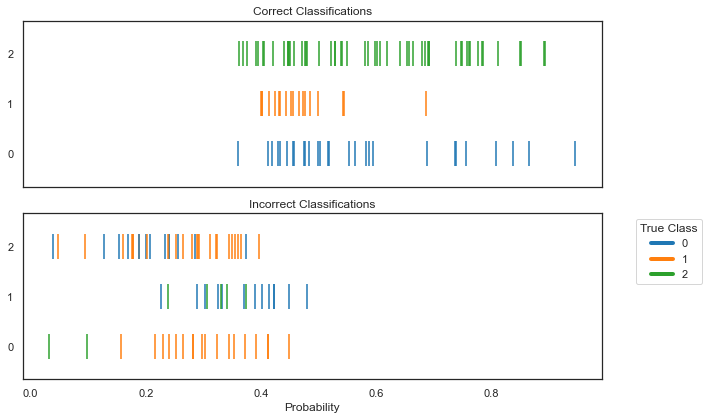

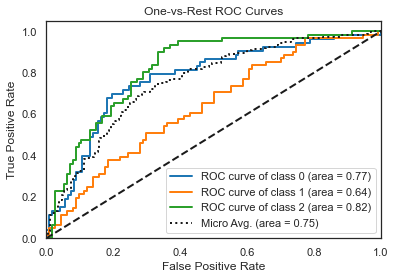

Optimal Thresholds: 
 {0: 0.3605663004679639, 1: 0.22941748079591773, 2: 0.36215459569142433}


<Figure size 576x432 with 0 Axes>

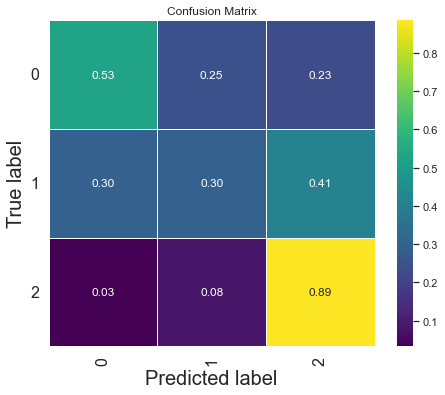

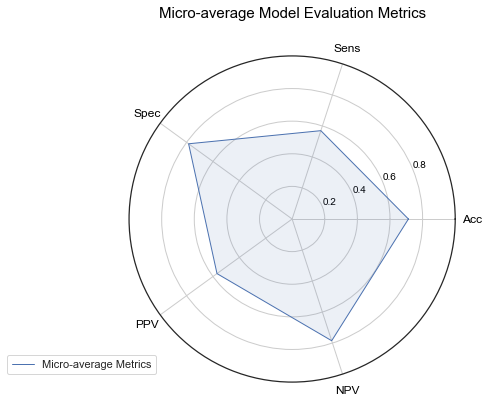

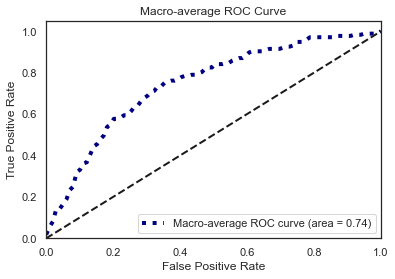

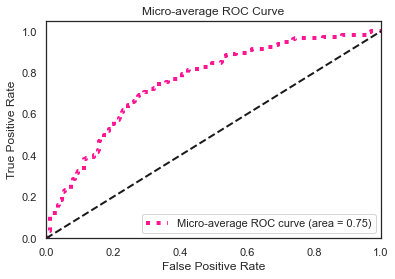

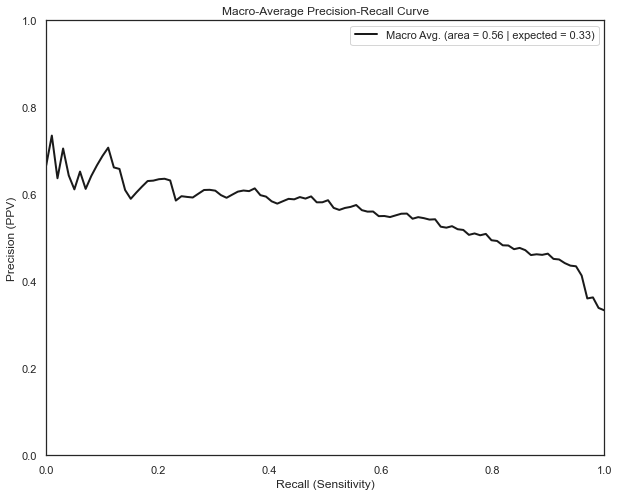

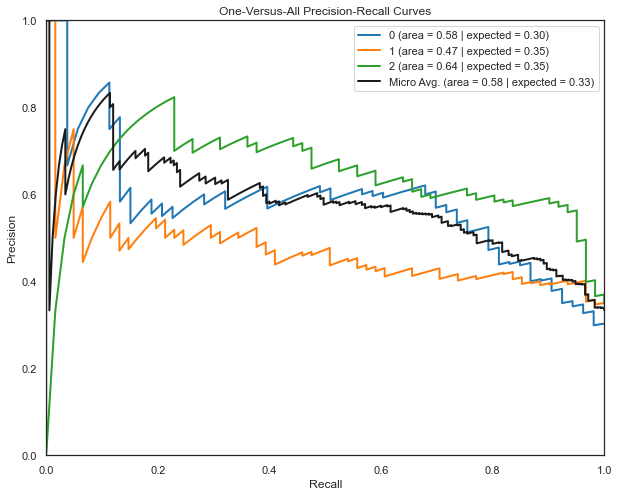

In [81]:
from calvin_utils.statistical_utils.classification_statistics import ComprehensiveMulticlassROC
evaluator = ComprehensiveMulticlassROC(fitted_model=results, predictions_df=None, observation_df=outcome_matrix, 
                                       normalization='true', thresholds=None, out_dir=out_dir+'/train_results')
evaluator.run()

Visuialize OVR CIs

Done  0
Done  1
Done  2


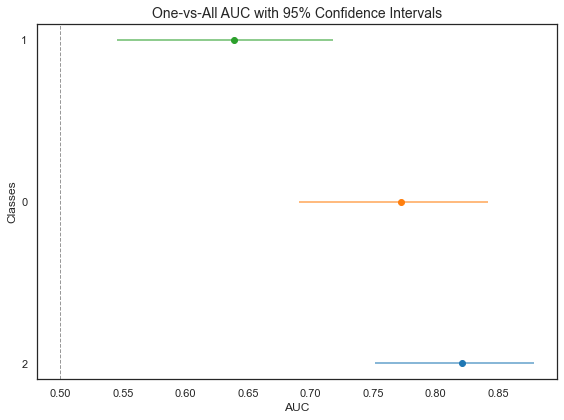

In [82]:
df, bootstrap  = evaluator.bootstrap_ovr_auroc(raw_observations=evaluator.raw_observations, raw_predictions=evaluator.raw_predictions, outcome_matrix_cols=evaluator.outcome_matrix.columns)
ComprehensiveMulticlassROC.plot_ovr_auc_with_ci(df, out_dir=out_dir+'/train_auc_per_diagnosis')

ADVANCED
- code specific manual thresholds to intervene upon classifications

Step 1: relate integer (index) to class

In [83]:
# evaluator.relate_index_to_class()

Step 2: in a dictionary of the indices (corresponding to class), key in the lambda function to edit the probability. 
- Code from left to right, giving priority to each method. 
- Example:
```
>thresholds = {
>            0: lambda probs: 0 if probs[0] > 0.5 else (1 if probs[0] > 0.25 else 2),  # Adjust class_0 predictions
>            1: lambda probs: None,  # No threshold adjustment for class_1
>            2: lambda probs: None   # No threshold adjustment for class_2
>        }
```

In [84]:
# thresholds = {
#     0: lambda prob: 0,  # Always keep class 0
#     1: lambda prob: 1,  # Always keep class 1
#     2: lambda prob: 2 if prob[2] > 0.5 else (1 if prob[1] > 0.3 else 0)  # Conditional adjustment for class 2
# }


Step 3: Check the effect

In [85]:
# from calvin_utils.statistical_utils.classification_statistics import ComprehensiveMulticlassROC
# evaluator = ComprehensiveMulticlassROC(fitted_model=results, observation_df=outcome_matrix, normalization='pred', thresholds=thresholds, out_dir=out_dir)
# evaluator.run()

Step 4: YOU MUST LOOCV AND VALIDATE IN OUT-OF-SAMPLE DATA.
- add thresholds as an argument to any further calls to ComprehensiveMulticlassROC

Bootstrap the Micro Average AUC

In [86]:
# import matplotlib
# from calvin_utils.statistical_utils.classification_statistics import bootstrap_auc
# matplotlib.use('Agg')  # Use a non-interactive backend

# mean_auc, lower_ci, upper_ci = bootstrap_auc(outcome_matrix, design_matrix, n_iterations=1000)
# print(f'Mean AUC: {mean_auc}, 95% CI: ({lower_ci}, {upper_ci})')

Permutation Test Two Different Formulas by Comparing Their AUCs

In [87]:
data_df.columns

Index(['subid', 'CSF_Cerebellum', 'CSF_Subcortex', 'CSF_MTL', 'CSF_Occipital',
       'CSF_Frontal', 'CSF_Parietal', 'CSF_Temporal', 'GM_Cerebellum',
       'GM_Subcortex', 'GM_MTL', 'GM_Occipital', 'GM_Frontal', 'GM_Parietal',
       'GM_Temporal', 'WM_Cerebellum', 'WM_Subcortex', 'WM_MTL',
       'WM_Occipital', 'WM_Frontal', 'WM_Parietal', 'WM_Temporal',
       'Visual_Frontal', 'Visual_Parietal', 'Visual_Occipital',
       'Visual_Temporal', 'Visual_Cerebellum', 'Visual_Subcortex',
       'Visual_MTL', 'Diagnosis', 'Sex', 'Age', 'Cohort', 'CTh_Cerebellum',
       'CTh_MTL', 'CTh_Occipital', 'CTh_Frontal', 'CTh_Parietal',
       'CTh_Temporal', 'CTh_Subcortex', 'Q4', 'TOTAL11', 'TOTALMOD',
       'DX_BASELINE', 'DX_M12'],
      dtype='object')

In [88]:
f1 = "DX_M12 ~ CSF_Cerebellum + CSF_Subcortex + CSF_MTL + CSF_Occipital + CSF_Frontal + CSF_Parietal + CSF_Temporal"
f2 = "Diagnosis ~ CTh_MTL + CTh_Occipital + CTh_Frontal + CTh_Parietal + CTh_Temporal"

In [89]:
# import matplotlib
# matplotlib.use('Agg')  # Use a non-interactive backend
# from calvin_utils.statistical_utils.classification_statistics import permute_auc_difference
# obs_diff, lower_ci, upper_ci, p_value = permute_auc_difference(data_df, formula1=f1, 
#                                                                   formula2=f2,
#                                                                   cal_palm=cal_palm, n_iterations=1000)
# print(f'Observde AUC Difference: {obs_diff}, 95% CI: ({lower_ci}, {upper_ci}), p-value: {p_value}')

# 06 - Visualize the Regression as a Forest Plot
- This will probably look poor if you ran a regression without standardizing your data. 

----Forest Plot For: 1 ----
Saved to /Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/atrophy_seeds_2023/Figures/supplement_validation_diagnostic/csf/forest_plots as regression_forest_plot.svg and .png
----Forest Plot For: 2 ----
Saved to /Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/atrophy_seeds_2023/Figures/supplement_validation_diagnostic/csf/forest_plots as regression_forest_plot.svg and .png


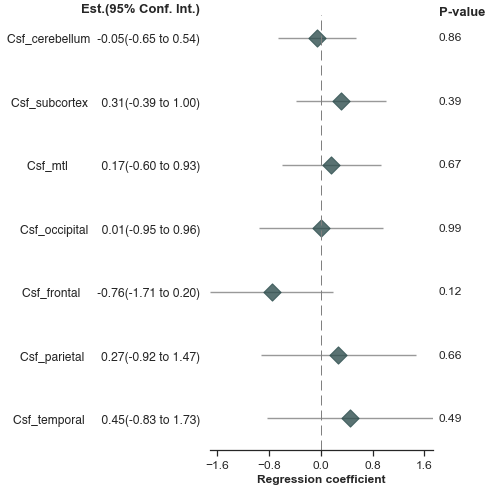

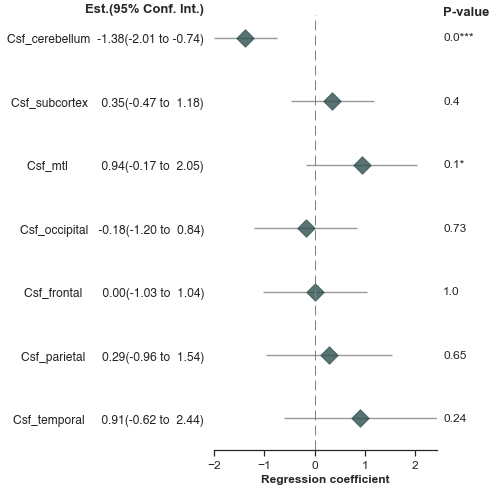

In [90]:
from calvin_utils.statistical_utils.statistical_measurements import MultinomialForestPlot
multinomial_forest = MultinomialForestPlot(model=results, sig_digits=2, out_dir=out_dir+'/forest_plots', table=False)
multinomial_forest.run()

# 07 - Generate Partial Dependence Plots

0:DX_BASELINE


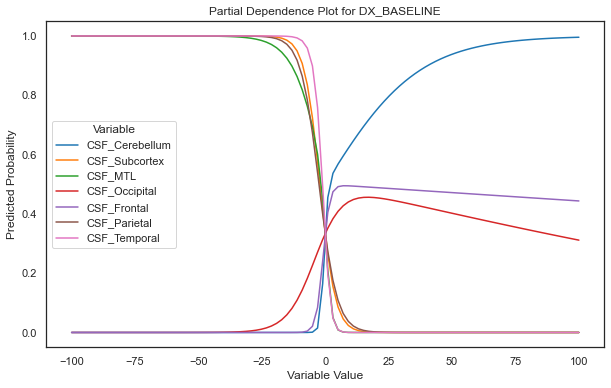

In [91]:
from calvin_utils.statistical_utils.statistical_measurements import PartialDependencePlot
pdp = PartialDependencePlot(formula=formula, data_df=data_df, model=results, design_matrix=design_matrix, outcomes_df=outcome_matrix, 
                            data_range=[-100,100], out_dir=out_dir+'/partial_dep_plots', marginal_method='mean', debug=False)
pdp.run()

# 08 - Visualize the Partial Regression Plots

Saved to /Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/atrophy_seeds_2023/Figures/supplement_validation_diagnostic/csf/partial_regression_plot/partial_regression_plot.svg


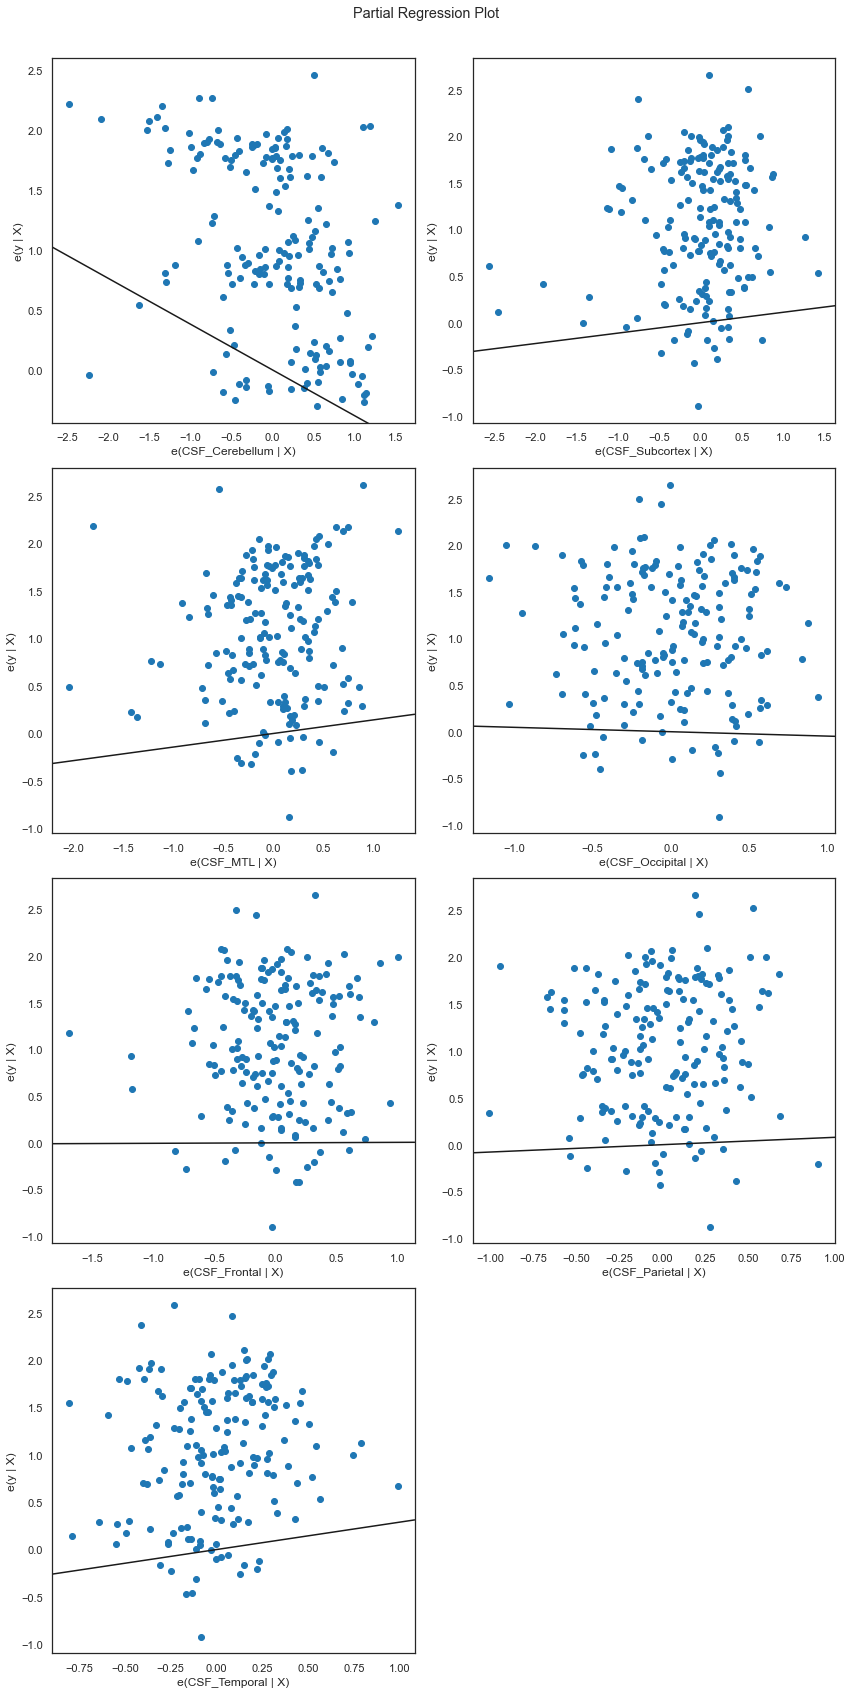

In [92]:
from calvin_utils.statistical_utils.statistical_measurements import PartialRegressionPlot
partial_plot = PartialRegressionPlot(model=results, design_matrix=design_matrix, out_dir=out_dir+'/partial_regression_plot', palette=None)
partial_plot = partial_plot.run()

# 09 - LOOCV

175it [00:05, 29.20it/s]


Taking maximum probability as prediction.
There are 53 observations for 0
There are 61 observations for 1
There are 61 observations for 2


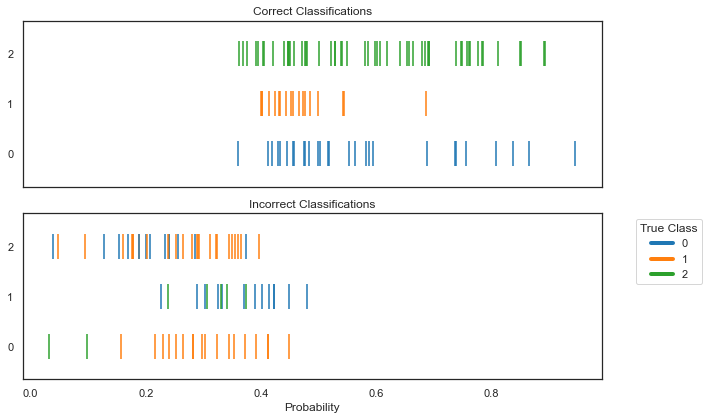

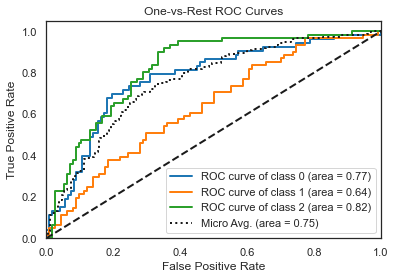

Optimal Thresholds: 
 {0: 0.3605663004679639, 1: 0.22941748079591773, 2: 0.36215459569142433}


<Figure size 576x432 with 0 Axes>

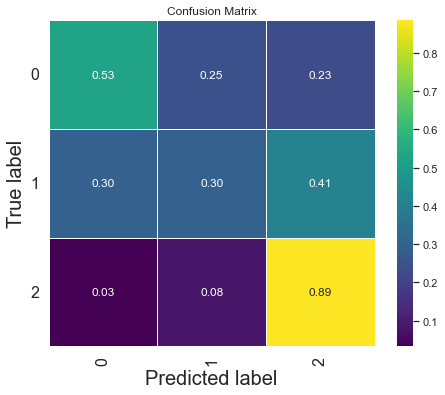

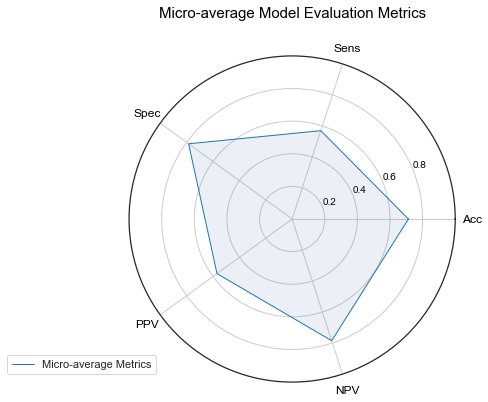

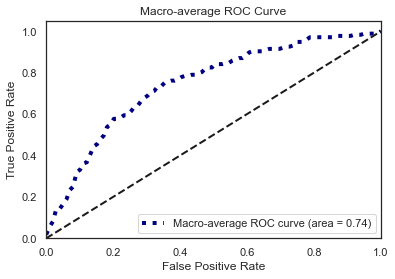

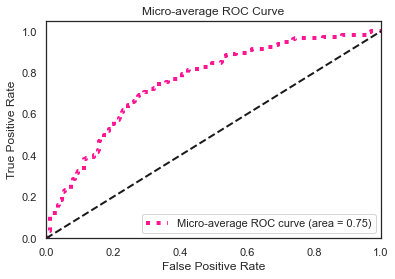

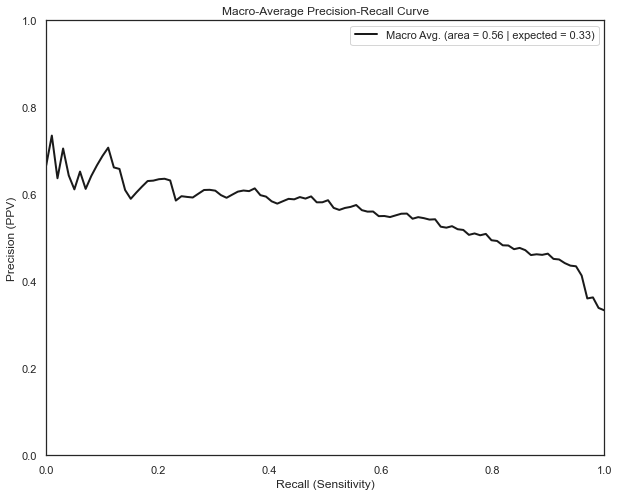

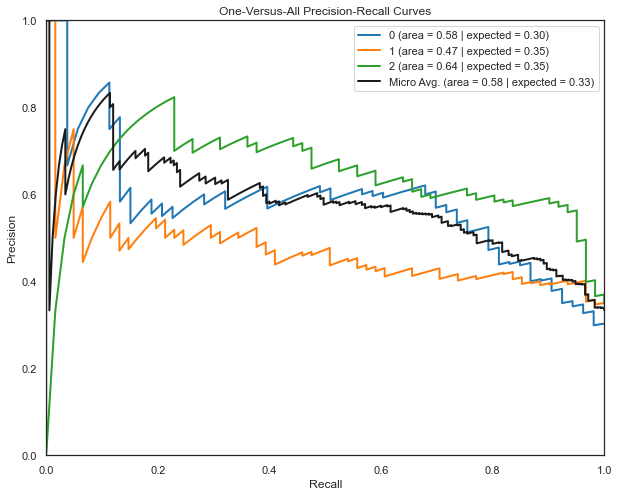

In [93]:
import pandas as pd
from calvin_utils.statistical_utils.logistic_regression import LogisticRegression
from calvin_utils.statistical_utils.classification_statistics import ComprehensiveMulticlassROC
y_true, y_pred, test_prob = LogisticRegression.run_loocv(outcome_matrix, design_matrix)
loocv_evaluator = ComprehensiveMulticlassROC(fitted_model=results, predictions_df=None, observation_df=outcome_matrix, normalization='true', thresholds=None, out_dir=out_dir+'/loocv_results')
loocv_evaluator.run()

Done  0
Done  1
Done  2


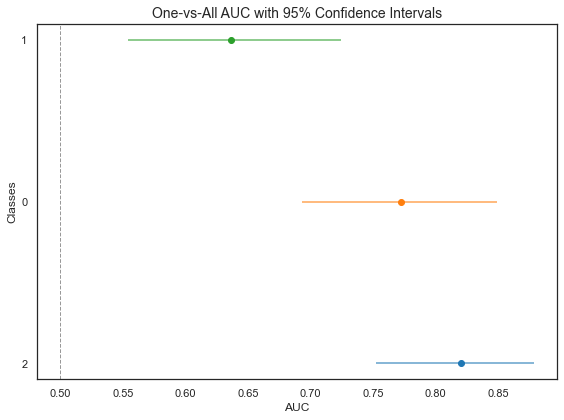

In [94]:
df, bootstrap  = loocv_evaluator.bootstrap_ovr_auroc(raw_observations=loocv_evaluator.raw_observations, raw_predictions=loocv_evaluator.raw_predictions, outcome_matrix_cols=loocv_evaluator.outcome_matrix.columns)
ComprehensiveMulticlassROC.plot_ovr_auc_with_ci(df, out_dir=out_dir+'/loocv_auc_per_diagnosis')

# 10 - Predict Unseen Data
- Unseen data is expected to be in a held-out CSV with the exact same naming conventions used by the training data

In [95]:
new_csv_path='/Volumes/HowExp/datasets/01a_ADNI_Alzheimer_Atrophy/metadata/cleaned_information/validation.csv'

Get New Data

In [96]:
from calvin_utils.permutation_analysis_utils.statsmodels_palm import CalvinStatsmodelsPalm
new_palm = CalvinStatsmodelsPalm(input_csv_path=new_csv_path, output_dir=out_dir+'/test_results', sheet=sheet)
other_df = new_palm.read_and_display_data()
other_df

,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,GM_Subcortex,...,CTh_Occipital,CTh_Frontal,CTh_Parietal,CTh_Temporal,CTh_Subcortex,Q4,TOTAL11,TOTALMOD,DX_BASELINE,DX_M12
0,002_S_0619,-35472.21632,-23876.106190,-1947.061673,-51088.10268,-81475.108430,-66818.85783,-72864.62884,-30069.234640,-10494.169140,...,-199.218424,-854.647087,-537.906934,-559.536577,0.0,10.0,19.33,30.33,Alzheimer,Alzheimer
1,002_S_0955,-27460.22888,-4223.645647,-1808.785280,-42136.37844,-25613.171140,-35525.69718,-43909.67109,13848.402800,6067.399085,...,-471.478613,-851.254149,-887.305933,-513.666153,0.0,9.0,20.67,31.67,Alzheimer,NaN
2,002_S_1018,-12574.75594,8513.644987,-94.284543,-14372.23896,-8599.629407,-15706.83518,-15822.41804,-28282.455710,15141.368210,...,-141.800604,145.391533,-160.305684,8.022922,0.0,8.0,9.00,17.00,Alzheimer,Alzheimer
3,002_S_4171,-22505.65009,1153.619287,-282.992524,-19830.70307,-39892.905180,-40357.36227,-45393.63636,9741.557543,17242.576070,...,12.351702,-235.485709,-251.586752,-271.527767,0.0,NaN,NaN,NaN,NaN,NaN
4,002_S_4213,-12551.77882,3813.413714,-258.413105,-18806.00577,-21864.023930,-14076.07048,-19597.14019,1706.118629,5676.846180,...,-5.523813,-70.171743,182.083312,-47.331574,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1183,018_S_0043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.0,7.00,10.00,Normal,Normal
1184,100_S_0035,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.0,6.00,9.00,Normal,Normal
1185,023_S_0030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,10.0,10.00,22.00,MCI,Alzheimer
1186,100_S_0015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.0,7.00,9.00,Normal,Normal


Remove Nans

In [97]:
other_df = new_palm.drop_nans_from_columns(columns_to_drop_from=drop_list)
display(other_df)

,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,GM_Subcortex,...,CTh_Occipital,CTh_Frontal,CTh_Parietal,CTh_Temporal,CTh_Subcortex,Q4,TOTAL11,TOTALMOD,DX_BASELINE,DX_M12
0,002_S_0619,-35472.216320,-23876.106190,-1947.061673,-51088.10268,-81475.108430,-66818.857830,-72864.62884,-30069.234640,-10494.169140,...,-199.218424,-854.647087,-537.906934,-559.536577,0.0,10.0,19.33,30.33,Alzheimer,Alzheimer
1,002_S_0955,-27460.228880,-4223.645647,-1808.785280,-42136.37844,-25613.171140,-35525.697180,-43909.67109,13848.402800,6067.399085,...,-471.478613,-851.254149,-887.305933,-513.666153,0.0,9.0,20.67,31.67,Alzheimer,NaN
2,002_S_1018,-12574.755940,8513.644987,-94.284543,-14372.23896,-8599.629407,-15706.835180,-15822.41804,-28282.455710,15141.368210,...,-141.800604,145.391533,-160.305684,8.022922,0.0,8.0,9.00,17.00,Alzheimer,Alzheimer
19,003_S_1059,-24108.470640,-10781.314700,-1600.680328,-32977.62286,-33980.868420,-42764.547270,-43597.03495,16817.200220,11659.702010,...,-368.865173,-797.065053,-884.485216,-567.778349,0.0,8.0,15.33,25.33,Alzheimer,Alzheimer
20,003_S_1257,-39850.785370,-51587.474810,-4405.871162,-56695.38195,-59945.585440,-57934.726150,-75261.59588,-21115.447460,-51825.710620,...,-192.849665,-624.999432,-489.465906,-523.552840,0.0,10.0,30.33,42.33,Alzheimer,Alzheimer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,941_S_1197,-13872.558410,4601.684568,-458.421924,-16817.12255,-21263.165420,-23822.893740,-23093.12069,4174.322515,20783.922910,...,-225.443108,-464.078384,-487.847860,-161.284259,0.0,4.0,6.33,11.33,Normal,Normal
1090,941_S_1203,-8536.033876,3546.800696,-97.105074,-17019.96759,-17954.145460,-24064.472130,-16193.06243,-20234.921810,16171.366210,...,-270.794551,84.474262,-343.373749,24.108729,0.0,4.0,6.33,10.33,Normal,Normal
1091,941_S_1295,-21425.028080,-7503.054536,-1148.289402,-31590.37147,-54998.175370,-35886.096130,-49273.73571,-6201.197900,9389.125887,...,-164.768952,-370.903081,-405.169890,-242.885731,0.0,6.0,14.33,20.33,MCI,MCI
1092,941_S_1311,-27931.833440,-18230.854220,-2041.659358,-29198.45084,-40067.353340,-33367.429880,-50108.03203,-7522.223335,-23928.050200,...,-182.056481,-565.863080,-672.765743,-443.672545,0.0,5.0,13.33,18.33,MCI,Alzheimer


Drop specific columns

In [98]:
column = 'Challenge'  # The column you'd like to evaluate
condition = 'equal'  # The condition to check ('equal', 'above', 'below', 'not')
value = 1 # The value to drop if found

In [99]:
# other_df, _ = new_palm.drop_rows_based_on_value(column, condition, value)
display(other_df)

,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,GM_Subcortex,...,CTh_Occipital,CTh_Frontal,CTh_Parietal,CTh_Temporal,CTh_Subcortex,Q4,TOTAL11,TOTALMOD,DX_BASELINE,DX_M12
0,002_S_0619,-35472.216320,-23876.106190,-1947.061673,-51088.10268,-81475.108430,-66818.857830,-72864.62884,-30069.234640,-10494.169140,...,-199.218424,-854.647087,-537.906934,-559.536577,0.0,10.0,19.33,30.33,Alzheimer,Alzheimer
1,002_S_0955,-27460.228880,-4223.645647,-1808.785280,-42136.37844,-25613.171140,-35525.697180,-43909.67109,13848.402800,6067.399085,...,-471.478613,-851.254149,-887.305933,-513.666153,0.0,9.0,20.67,31.67,Alzheimer,NaN
2,002_S_1018,-12574.755940,8513.644987,-94.284543,-14372.23896,-8599.629407,-15706.835180,-15822.41804,-28282.455710,15141.368210,...,-141.800604,145.391533,-160.305684,8.022922,0.0,8.0,9.00,17.00,Alzheimer,Alzheimer
19,003_S_1059,-24108.470640,-10781.314700,-1600.680328,-32977.62286,-33980.868420,-42764.547270,-43597.03495,16817.200220,11659.702010,...,-368.865173,-797.065053,-884.485216,-567.778349,0.0,8.0,15.33,25.33,Alzheimer,Alzheimer
20,003_S_1257,-39850.785370,-51587.474810,-4405.871162,-56695.38195,-59945.585440,-57934.726150,-75261.59588,-21115.447460,-51825.710620,...,-192.849665,-624.999432,-489.465906,-523.552840,0.0,10.0,30.33,42.33,Alzheimer,Alzheimer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,941_S_1197,-13872.558410,4601.684568,-458.421924,-16817.12255,-21263.165420,-23822.893740,-23093.12069,4174.322515,20783.922910,...,-225.443108,-464.078384,-487.847860,-161.284259,0.0,4.0,6.33,11.33,Normal,Normal
1090,941_S_1203,-8536.033876,3546.800696,-97.105074,-17019.96759,-17954.145460,-24064.472130,-16193.06243,-20234.921810,16171.366210,...,-270.794551,84.474262,-343.373749,24.108729,0.0,4.0,6.33,10.33,Normal,Normal
1091,941_S_1295,-21425.028080,-7503.054536,-1148.289402,-31590.37147,-54998.175370,-35886.096130,-49273.73571,-6201.197900,9389.125887,...,-164.768952,-370.903081,-405.169890,-242.885731,0.0,6.0,14.33,20.33,MCI,MCI
1092,941_S_1311,-27931.833440,-18230.854220,-2041.659358,-29198.45084,-40067.353340,-33367.429880,-50108.03203,-7522.223335,-23928.050200,...,-182.056481,-565.863080,-672.765743,-443.672545,0.0,5.0,13.33,18.33,MCI,Alzheimer


Standardize

In [100]:
other_df = new_palm.standardize_columns(cols_not_to_standardize)
other_df

Unable to standardize column Diagnosis.
Unable to standardize column DX_M12.


,subid,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal,GM_Cerebellum,GM_Subcortex,...,CTh_Occipital,CTh_Frontal,CTh_Parietal,CTh_Temporal,CTh_Subcortex,Q4,TOTAL11,TOTALMOD,DX_BASELINE,DX_M12
0,002_S_0619,-1.344509,-2.255307,-1.490767,-2.362515,-2.681077,-2.553510,-2.393607,-1.038911,-0.549301,...,-0.225094,-1.622255,-0.391822,-1.649400,NaN,1.466690,1.223239,1.295352,Alzheimer,Alzheimer
1,002_S_0955,-0.567789,-0.213259,-1.314136,-1.574944,0.143474,-0.504135,-0.654940,1.412522,0.140512,...,-2.449579,-1.611986,-1.458994,-1.427495,NaN,1.112683,1.436867,1.439717,Alzheimer,NaN
2,002_S_1018,0.875279,1.110247,0.875939,0.867741,1.003731,0.793794,1.031625,-0.939175,0.518455,...,0.244035,1.404312,0.761489,1.096254,NaN,0.758677,-0.423612,-0.140755,Alzheimer,Alzheimer
19,003_S_1059,-0.242854,-0.894653,-1.048306,-0.769158,-0.279623,-0.978204,-0.636167,1.578237,0.373439,...,-1.611182,-1.447986,-1.450379,-1.689270,NaN,0.758677,0.585543,0.756677,Alzheimer,Alzheimer
20,003_S_1257,-1.768988,-5.134739,-4.631609,-2.855843,-1.592478,-1.971692,-2.537539,-0.539121,-2.270818,...,-0.173059,-0.927238,-0.243868,-1.475323,NaN,1.466690,2.976904,2.588172,Alzheimer,Alzheimer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,941_S_1197,0.749464,0.703764,0.410796,0.652640,0.363423,0.262277,0.595038,0.872526,0.753476,...,-0.439361,-0.440218,-0.238926,0.277206,NaN,-0.657351,-0.849274,-0.751612,Normal,Normal
1090,941_S_1203,1.266812,0.594153,0.872336,0.634794,0.530738,0.246456,1.009368,-0.489971,0.561356,...,-0.809902,1.219948,0.202342,1.174072,NaN,-0.657351,-0.849274,-0.859347,Normal,Normal
1091,941_S_1295,0.017292,-0.554016,-0.470429,-0.647108,-1.342322,-0.527737,-0.977037,0.293376,0.278866,...,0.056373,-0.158228,0.013598,-0.117554,NaN,0.050663,0.426119,0.218002,MCI,MCI
1092,941_S_1311,-0.613509,-1.668720,-1.611605,-0.436667,-0.587374,-0.362791,-1.027135,0.219638,-1.108841,...,-0.084874,-0.748265,-0.803722,-1.088890,NaN,-0.303344,0.266695,0.002532,MCI,Alzheimer


Ordinalize

In [102]:
from calvin_utils.file_utils.dataframe_utilities import convert_to_ordinal
other_df, new_map = convert_to_ordinal(other_df, ['DX_BASELINE'])

Mapping of unique values to ordinal values:
DX_BASELINE: {'Alzheimer': 0, 'MCI': 1, 'Normal': 2}


Prepare Data

In [103]:
import pandas as pd
other_outcome_matrix, other_design_matrix = new_palm.define_design_matrix(formula, other_df, add_intercept=True)

other_design_matrix

,CSF_Cerebellum,CSF_Subcortex,CSF_MTL,CSF_Occipital,CSF_Frontal,CSF_Parietal,CSF_Temporal
0,-1.344509,-2.255307,-1.490767,-2.362515,-2.681077,-2.553510,-2.393607
1,-0.567789,-0.213259,-1.314136,-1.574944,0.143474,-0.504135,-0.654940
2,0.875279,1.110247,0.875939,0.867741,1.003731,0.793794,1.031625
19,-0.242854,-0.894653,-1.048306,-0.769158,-0.279623,-0.978204,-0.636167
20,-1.768988,-5.134739,-4.631609,-2.855843,-1.592478,-1.971692,-2.537539
...,...,...,...,...,...,...,...
1089,0.749464,0.703764,0.410796,0.652640,0.363423,0.262277,0.595038
1090,1.266812,0.594153,0.872336,0.634794,0.530738,0.246456,1.009368
1091,0.017292,-0.554016,-0.470429,-0.647108,-1.342322,-0.527737,-0.977037
1092,-0.613509,-1.668720,-1.611605,-0.436667,-0.587374,-0.362791,-1.027135


Predict

In [104]:
choice = 'Logistic'

In [105]:
predictions_df = results.predict(other_design_matrix)

In [109]:
# thresholds = {
#     0: lambda prob: 0 if prob < 0.33 else 1,
#     1: lambda prob: 1 if prob > 0.33 else 0
# }

Taking maximum probability as prediction.
There are 118 observations for 0
There are 297 observations for 1
There are 144 observations for 2


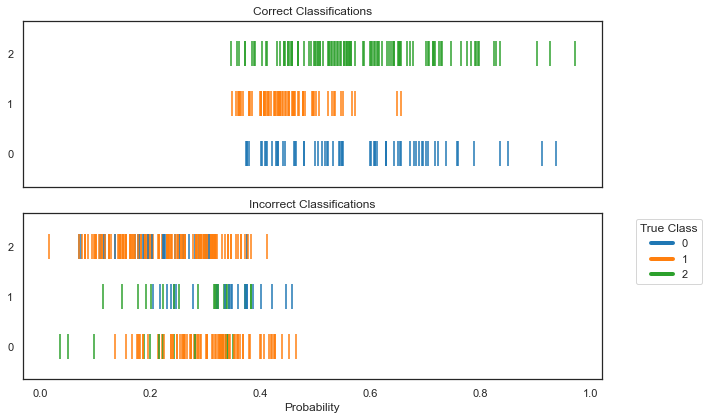

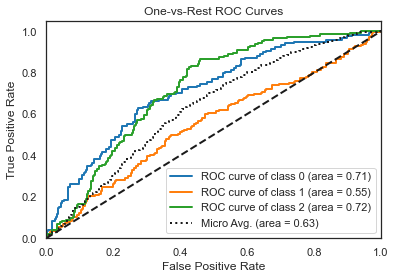

Optimal Thresholds: 
 {0: 0.3737301123480254, 1: 0.28273680774132165, 2: 0.3156215734219612}


<Figure size 576x432 with 0 Axes>

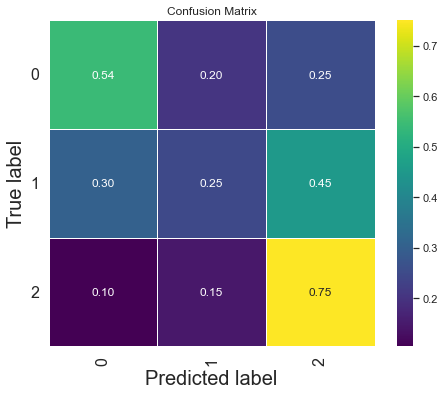

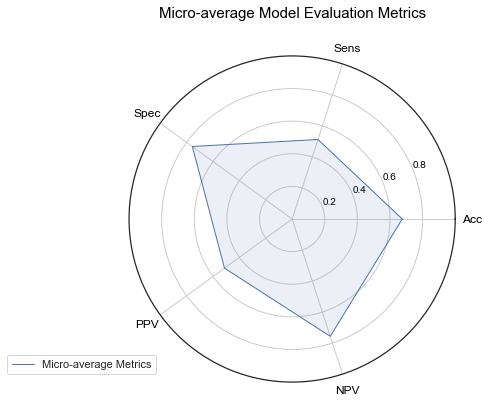

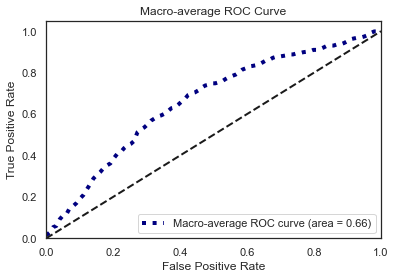

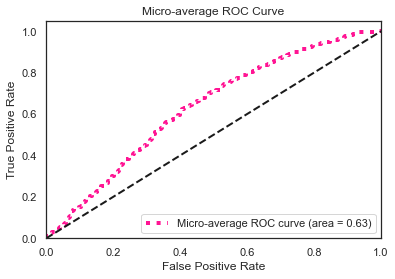

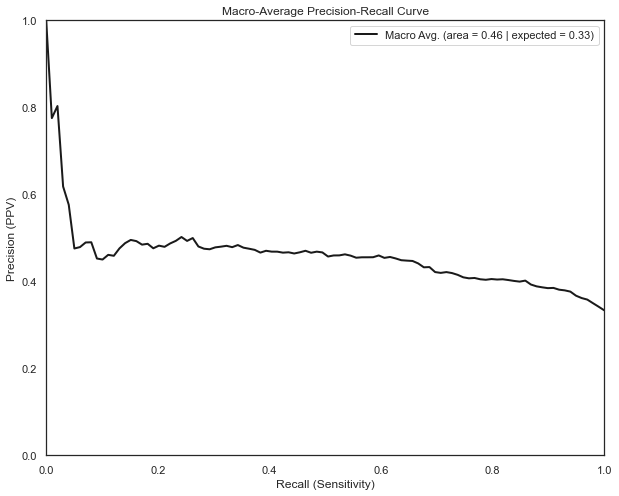

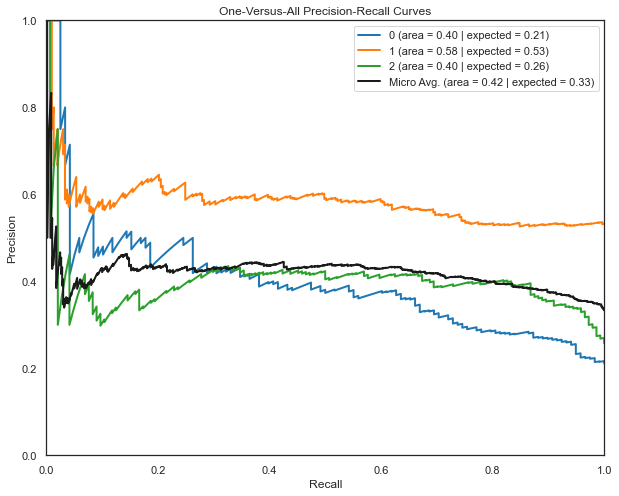

In [110]:
from calvin_utils.statistical_utils.classification_statistics import ComprehensiveMulticlassROC
loocv_evaluator = ComprehensiveMulticlassROC(fitted_model=None, predictions_df=predictions_df, observation_df=other_outcome_matrix, normalization='true', thresholds=None, out_dir=out_dir+'/test_results')
loocv_evaluator.run() 

In [ ]:
loocv_evaluator.save_dataframes()

Get One Vs. All Confidence Intervals on AUC

In [ ]:
df, bootstrap = ComprehensiveMulticlassROC.bootstrap_ovr_auroc(raw_observations=loocv_evaluator.raw_observations, raw_predictions=loocv_evaluator.raw_predictions, outcome_matrix_cols=loocv_evaluator.outcome_matrix.columns)
ComprehensiveMulticlassROC.plot_ovr_auc_with_ci(df, out_dir=out_dir+'/test_auc_per_diagnosis')

In [ ]:
display(df)

Get Confidence Intervals on Sensitivity, Specificity, NPV, PPV, and Accuracy for Each Class

In [ ]:
from calvin_utils.statistical_utils.classification_statistics import calculate_youden_and_metrics, save_dfs
dfs, youden_dict = calculate_youden_and_metrics(raw_observations=loocv_evaluator.raw_observations, 
                                                raw_predictions=loocv_evaluator.raw_predictions, 
                                                outcome_matrix_cols=loocv_evaluator.outcome_matrix.columns,
                                                out_dir=out_dir+'/metrics_per_diagnosis')
save_dfs(dfs, out_dir=out_dir+'/metrics_per_diagnosis')

In [ ]:
ComprehensiveMulticlassROC.generate_all_plots(dfs, out_dir=out_dir+'/metrics_per_diagnosis')

Get Overall Micro Average AUC

In [ ]:
loocv_evaluator.get_micro_auc()

That's all

-Calvin